In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def fastread(str):
    try:
        data = pd.read_csv(str, header=None, sep='\s+', dtype=np.float64)
    except:
        data = pd.read_csv(str, header=None, sep='\s+', skipfooter=1, dtype=np.float64)
    return data

def fastread_np(str):
    return fastread(str).to_numpy()

In [4]:
curr = fastread_np(r'./moment-test/current_L_100.dat')
tc = fastread_np(r'./moment-test/time_100.dat')
-curr[-1]

array([-0.00035934])

Text(0, 0.5, 'current')

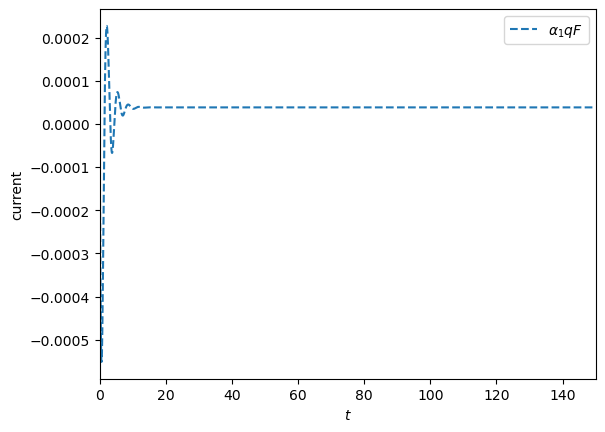

In [3]:
data = fastread_np(r'.//traces_2r.txt')
t = data[:, 0]
tracet = np.reshape(data[:, 1:], (len(t), 5, 2))
tracet = tracet[:, :, 0] + tracet[:, :, 1] * 1j
tracet[:, 2].real[-1]
alpha = -0.005
currt = 0.1 * tracet[:, 2] * 1 + alpha * tracet[:, 4] * 0
# plt.plot(tc, curr_L.real, label='Re')
# plt.plot(tc, -curr, label= r"$\alpha_1 q F$")
plt.plot(t, currt.real, '--', label= r"$\alpha_1 q F$")
# plt.plot(t, tracet[:, 3].imag)
plt.legend()
plt.xlim([0,150])
plt.xlabel(r'$t$')
plt.ylabel(r'current')
# plt.ylim([-0.000,0.003])

# plt.plot(t, tracet[:, 1])
# plt.plot(t, tracet[:, 2].real)
# plt.plot(t, tracet[:, 2].imag)

(-0.0001, 0.0007)

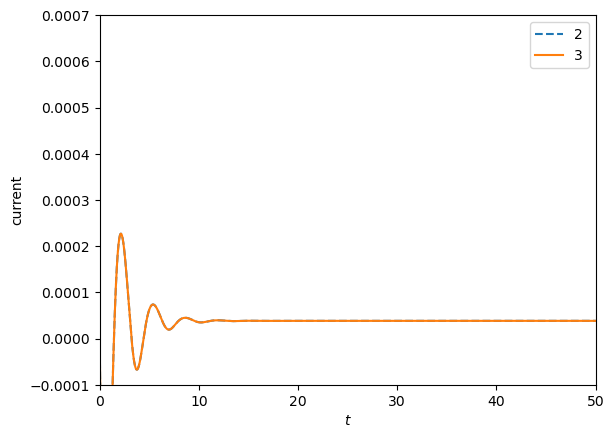

In [5]:
data1 = fastread_np(r'.//traces_3r.txt')
t1 = data1[:, 0]
tracet1 = np.reshape(data1[:, 1:], (len(t1), 5, 2))
tracet1 = tracet1[:, :, 0] + tracet1[:, :, 1] * 1j
tracet1[:, 2].real[-1]
alpha1 = -0.001
currt1 = 0.1 * tracet1[:, 2] * 1 + alpha1 * tracet1[:, 4] * 0
# plt.plot(tc, curr_L.real, label='Re')
# plt.plot(tc, -curr, label= r"$\alpha_1 q F$")
plt.plot(t, currt.real, '--', label= r"2")
plt.plot(t1, currt1.real, label= r"3")
# plt.plot(t, tracet[:, 3].imag)
plt.legend()
plt.xlim([0,50])
plt.xlabel(r'$t$')
plt.ylabel(r'current')
plt.ylim([-0.0001,0.0007])

In [ ]:
plt.plot(t, tracet[:, 4].real, label='Re')
plt.plot(t, tracet[:, 4].imag, label='Im')
plt.legend()
plt.ylim([tracet[-1, 4] - 0.000001, tracet[-1, 4] + 0.000001])

In [ ]:
alpha = -0.005
I = tracet[:, 2] + alpha * tracet[:, 4]
plt.plot(t, I.real)
plt.plot(t, I.imag)
plt.legend()
plt.ylim([I[-1] - 0.0001,I[-1] + 0.0001])
# plt.xlim([8,10])

# plt.plot(t, tracet[:, 1])
# plt.plot(t, tracet[:, 2].real)
# plt.plot(t, tracet[:, 2].imag)

In [ ]:
expn1 = np.loadtxt(r'.//expn1.dat', dtype=np.complex128)
expn2 = np.loadtxt(r'.//expn2.dat', dtype=np.complex128)
etaa1 = np.loadtxt(r'.//etaa1.dat')
etaa2 = np.loadtxt(r'.//etaa2.dat')
etaa = np.append(etaa1, etaa2)
nind = len(expn1) + len(expn2)

data1 = fastread_np(r'.//curr.txt')
t1 = data1[:, 0]
currt = np.reshape(data1[:, 1:], (len(t1), nind, nind, 2))
currt = currt[:, :, :, 0] + currt[:, :, :, 1] * 1j

for i in range(nind):
  for j in range(nind):
    if i == j:
      currt[:, i, i] = currt[:, i, i] * np.sqrt(etaa[i] * etaa[i] * 2)
    else:
      # print(i, j)
      currt[:, i, j] = currt[:, i, j] * np.sqrt(etaa[i] * etaa[j])

F_L = np.zeros(len(t1), dtype=complex)
for i in range(len(expn1)):
  for j in range(len(expn1)):
    # sum_curr_L += currt[:, i, j + len(etal1)] * expn1[i]
    # sum_curr_L += currt[:, i, j + len(etal1)] 
    F_L += currt[:, i, j] 
    
curr_L = np.zeros(len(t1), dtype=complex)
for i in range(len(expn1)):
  for j in range(len(expn2)):
    curr_L += -currt[:, i, j + len(expn1)] * expn1[i]

# plt.plot(t1, F_L.real, label='Re')
# plt.plot(t1, F_L.imag, label='Im')

plt.plot(t1, curr_L.real, label='Re')
plt.plot(t1, curr_L.imag, label='Im')
plt.legend()

In [ ]:
plt.plot(t1, sum_curr_L.real, label='Re')
plt.plot(t1, sum_curr_L.imag, label='Im')

In [141]:
# [(0.5, 1.2, 1)],  # lamd, omgs, zeta
omgs = 2
zeta = 3.5
(zeta / (omgs * 2))**2
    

0.765625